# AP 155 Lab Exercise
---
## Exercise 1: Idiomatic Python

_Instructions_: 
- **Report figure (Problem 1):** Plot the 2D wave interference pattern between 2 (or more) coherent sources. Include at least 1 figure.
- **Report discussion (Problem 2):** Write a custom `matrix_multiply()`function using Python list comprehensions without external libraries (do not use `np.dot()` or `@`).
    - (i) For larger matrices, which is preferred, the custom `matrix_multiply()` or the `@` operator... why?
    - (ii) What are the general benefits of writing idiomatic Python?
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name_: Castaneda, Joaquin
- _Student No._: 2024-09743
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1

![Wave interference pattern](wave_interference_v2.png)

**Figure 1.** 2D interference pattern produced by two coherent wave sources located at $(-1,0)$ and $(1,0)$. The plot shows the combined wave amplitude across the region from $-4$ to $4$ in both the $x$ and $y$ directions.

### Problem 2 

The functions developed in Problem 2 show how basic matrix operations can be done using Python lists without relying on external libraries such as NumPy. The `matrix_multiply()` function calculates the result by taking the scalar product of each row of the left matrix with each column of the right matrix. For larger matrices, the `@` operator is generally preferred because it is much simpler to write and can be much faster when working with optimized libraries such as NumPy. However, writing the function ourselves makes it easier to understand what is actually happening during matrix multiplication. It also gave me practice with loops, lists, functions, and using functions together. Writing idiomatic Python is useful because it can make code shorter, clearer, and easier to maintain. List comprehensions are one example of this. However, simpler code is not always better if it makes the underlying process harder to understand, especially when learning a new concept.

### Other comments
- This activity challenged me to work without NumPy and instead build the matrix operations using basic Python logic.


---
## Section 2: Code

### Problem 1: 2D Wave interference (Gezerlis Problem 1.15)

Assume that the combined eﬀect of two objects dropped in a water basin can be modelled by:
$$ W(\textbf{r}) = A \sin (k|\textbf{r}-\textbf{r}_0|) + A  \sin (k|\textbf{r}-\textbf{r}_1|). $$ You can think of this as an updated version of Eq. (1.3) in the book, where we are dealing with the linear addition of sinusoidal waves, instead of electric-field contributions. For simplicity, take $A=1$, $k=2\pi/0.3$, $r_0 = (−1, 0)$ , and $r_1 = (1, 0)$. Since we are now faced with a density plot, you should employ, NOT `streamplot()` but, `imshow()` from `Matplotlib`; in each of $x$ and $y$ your plot should extend from $−4$ to $+4$.

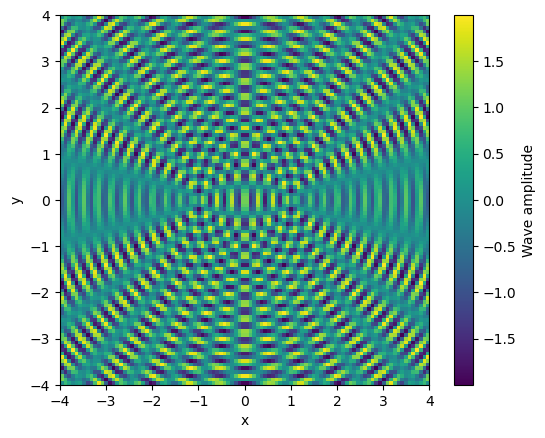

In [68]:
import matplotlib.pyplot as plt
from math import pi, sin, sqrt
import numpy as np

# Constants & Given
A = 1
k = (2*pi)/0.3
r_0 = (-1, 0)
r_1 = (1, 0)

# Generate values from -4 to 4 for X and Y
X = np.linspace(-4, 4, 100)
Y = X.copy()

# Empty list to store the full 2D wave matrix
w = []

for y in Y:
    row = [] # Empty list to store wave values for one y-coordinate

    for x in X:
        # Calculate distance from (x, y) to each wave source
        r0 = sqrt((x - r_0[0])**2 + (y - r_0[1])**2)
        r1 = sqrt((x - r_1[0])**2 + (y - r_1[1])**2)

        # Calculate combined wave at (x, y)
        W = A*sin(k*r0) + A*sin(k*r1)
        row.append(W) # Add W to the current row

    w.append(row) # Add the completed row to the matrix

# Plotting
plt.imshow(w, extent=[-4, 4, -4, 4]) # Set the plot range from -4 to 4
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='Wave amplitude')
plt.savefig('wave_interference_v2.png', dpi=300, bbox_inches='tight') # save the figure
plt.show()

#### Problem 1 code summary:

This script calculates the combined wave from two sources at each point on a 2D grid and displays the resulting interference pattern using `imshow()`. I used nested loops to go through each point, calculate its distance from both sources, and then use those distances to calculate the combined wave value. The values are stored in a list of lists so they can be displayed as a 2D density plot.

### Problem 2: Listcomps-maxxing

Import the `random` library (docs: https://docs.python.org/3/library/random.html). We will be using the `random.randint` function to pick random integers.

In [54]:
import random
number = random.randint(1, 9)
number

8

a. Create a function `random_integer_matrix(nrows, ncols)` that generates a matrix in the form of "list-of-lists" whose elements are random integers from $1$ to $9$. Each "sub-list" inside the main list is a row in the matrix.

In [61]:
import random

def random_integer_matrix(nrows, ncols):
    row_list = [] # Empty list to store rows of the matrix
    for i in range(nrows): # Repeat process for each row
        # Generate ncols random integers from 1 to 9 for the current row
        sublist = [random.randint(1, 9) for i in range(ncols)] 
        row_list.append(sublist) # Add the row to the matrix
    return row_list

random_integer_matrix(3, 4) # call the function to create a 3x4 matrix

[[5, 2, 8, 7], [7, 9, 2, 7], [1, 1, 8, 5]]

#### Problem 2(a) code summary:

This script creates a matrix with the number of rows and columns given by the user, with each entry filled with a random integer from 1 to 9. I used a loop to build the matrix one row at a time and a list comprehension to generate the random numbers for each row.

b. Create a function `scalar_product(list1, list2)` where you multiply each element at the same index in the two lists and sum/accumulate the results.

In [62]:
# write your code for b here

list1 = [1, 2, 3, 4]
list2 = [5, 6, 7, 8]

def scalar_product(list1, list2):
    to_be_summed = [] # Empty list to store the products
    for i in range(len(list1)): # Go through each index of the lists
        # Multiply elements at the same index and store the result
        to_be_summed.append(list1[i]*list2[i])
    return sum(to_be_summed) # Add all the products and return the total

print(scalar_product(list1, list2)) # Calculate and print

70


#### Problem 2(b) code summary:

This script calculates the scalar product of two lists by multiplying the elements at the same index and adding the results together. I used a loop to go through each pair of elements and stored their products in a separate list before using `sum()` to get the final result.

c. Create a function `transpose_matrix(orig_matrix)` which returns the transpose of any matrix also in "list-of-lists" form. Do not assume the size of the matrix; figure it out within the function. Double-check that your implementations above work. Create a $3\times4$ random integer matrix, print it out and its transpose. The values and shape between the two should be consistent.

In [57]:
def transpose_matrix(orig_matrix):
    num_rows = len(orig_matrix)  # Get number of rows
    num_cols = len(orig_matrix[0])  # Get number of columns

    transposed = []  # Empty list to store transpose

    for c in range(num_cols):  # Loop through each col
        row = []  # Create new row
        for r in range(num_rows):  # Loop through each row
            row.append(orig_matrix[r][c])  # Add column element to the new row
        transposed.append(row)  # Add the completed row

    return transposed  # Return the transposed matrix

#### Problem 2(c) code summary:

This function takes a matrix in list-of-lists form and creates its transpose by turning each column into a row. I used nested loops to go through the matrix and build the transpose step by step, so it can also be applicable with matrices of different sizes.

d. Create a function `matrix_multiply(left_matrix, right_matrix)` which performs the matrix multiplication. Do not assume the matrices follow a specific shape. Here's some tips and strategies:
* Determine how many rows and columns the left and right matrices have. Which numbers should match in order for us to have valid matrix multiplication?
* Iterating the elements of "list-of-lists" gives us the rows, but we need to iterate the columns for the right matrix.
* Use the `transpose_matrix` function, then iteratively apply `scalar_product`.

In [ ]:
# write your code for d here

def matrix_multiply(left_matrix, right_matrix):
    # Get dimensions of both matrices
    left_rows = len(left_matrix)
    left_cols = len(left_matrix[0])
    right_rows = len(right_matrix)
    right_cols = len(right_matrix[0])

    # Check that the left matrix's columns match the right matrix's rows
    if left_cols != right_rows:
        return "Matrices cannot be multiplied"

    # Transpose right matrix so its columns become rows
    right_transposed = transpose_matrix(right_matrix)

    result = []  # Empty list to store the result

    # Go through each row of the left matrix
    for row in left_matrix:
        new_row = []  # Create a new row for the result

        # Go through each column of the right matrix
        for column in right_transposed:
            # Calculate the scalar product of the row and column
            value = scalar_product(row, column)
            new_row.append(value)

        result.append(new_row)  # Add completed row to the result

    return result  # Return matrix product

#### Problem 2(d) code summary

This function multiplies two matrices by taking the scalar product of each row from the left matrix with each column from the right matrix. I transposed the right matrix so its columns become rows, making it easier to use the `scalar_product` function and build the result one row at a time.

**End of Exercise 1.**